In [5]:
import numpy as np

Variables: ['X0', 'X1', 'X2', 'X3']

Adjacency Matrix:
[[0 1 1 0]
 [0 0 0 1]
 [0 0 0 1]
 [0 0 0 0]]

Sample Data (first 5 rows):
         X0        X1        X2        X3
0  0.638182 -1.617806  3.043009  4.165079
1 -0.095221 -1.435968 -0.684129 -3.659566
2 -1.006269 -0.269289 -2.151390 -2.218738
3  2.675820  2.928985  5.216748  9.826790
4 -0.095201 -0.401367 -0.054828 -0.270788

Structural Equations:
X0 = ε0
X1 = w01*X0 + ε1
X2 = w02*X0 + ε2
X3 = w13*X1 + w23*X2 + ε3

Learned DAG Matrix (with edge weights):
     X0   X1   X2   X3
X0  0.0  0.7  0.5  0.0
X1  0.0  0.0  0.0  1.2
X2  0.0  0.0  0.0  0.8
X3  0.0  0.0  0.0  0.0


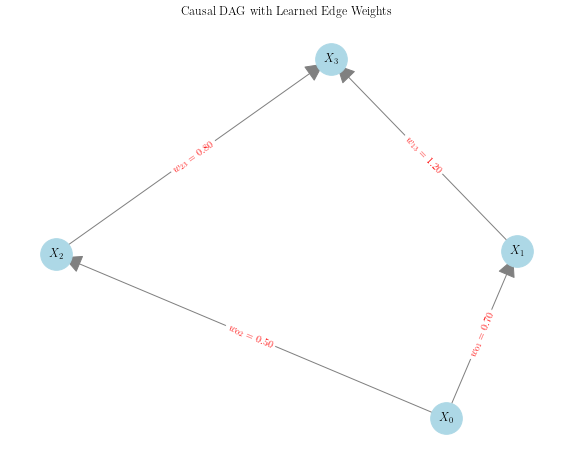

In [6]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from causal_dataset_generator import CausalDatasetGenerator

# Enable LaTeX rendering for Matplotlib
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] # Specify Times New Roman if available

# 1. Define an adjacency matrix for a sample DAG
# Example: 0 -> 1, 0 -> 2, 1 -> 3, 2 -> 3
adj_matrix = np.array([
    [0, 1, 1, 0],
    [0, 0, 0, 1],
    [0, 0, 0, 1],
    [0, 0, 0, 0]
])

# 2. Create an instance of CausalDatasetGenerator
generator = CausalDatasetGenerator(adj_matrix)

# 3. Get the list of variables
num_variables = generator.n
variables = [f"X{i}" for i in range(num_variables)]
print("Variables:", variables)

# 4. Print the adjacency matrix
print("\nAdjacency Matrix:")
print(adj_matrix)

# 5. Generate a dataset (optional, but shows the variables in action)
df, equations = generator.generate_dataset_from_dag(n_samples=100, nonlinear=False)
print("\nSample Data (first 5 rows):")
print(df.head())
print("\nStructural Equations:")
for var, eq in equations.items():
    print(eq)

# Assume learned_dag_matrix_df is available, for demonstration, let's create a sample
# In a real scenario, this would come from a causal discovery algorithm
learned_dag_matrix = np.array([
    [0.0, 0.7, 0.5, 0.0],
    [0.0, 0.0, 0.0, 1.2],
    [0.0, 0.0, 0.0, 0.8],
    [0.0, 0.0, 0.0, 0.0]
])
learned_dag_matrix_df = pd.DataFrame(learned_dag_matrix, columns=variables, index=variables)
print("\nLearned DAG Matrix (with edge weights):")
print(learned_dag_matrix_df)


# 6. Plot the DAG with edge labels
G = nx.DiGraph(learned_dag_matrix_df.values) # Use the learned matrix for plotting
pos = nx.spring_layout(G)  # You can choose different layout algorithms
labels = {i: f"$X_{i}$" for i in range(num_variables)} # Format node labels as LaTeX

plt.figure(figsize=(10, 8), facecolor='white') # Set figure facecolor to white for opaque background
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=1000) # Nodes twice smaller
nx.draw_networkx_edges(G, pos, edge_color='gray', arrowsize=40, arrowstyle='-|>') # Increased arrowsize
nx.draw_networkx_labels(G, pos, labels, font_size=12, font_weight='bold', font_family='serif') # Changed font_family

# Add edge labels
edge_labels = {}
for i in range(num_variables):
    for j in range(num_variables):
        weight = learned_dag_matrix_df.iloc[i, j]
        if weight != 0:
            # Format edge labels as LaTeX math
            edge_labels[(i, j)] = f"$w_{{{i}{j}}} = {weight:.2f}$"

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=10, font_family='serif') # Changed font_family

plt.title("Causal DAG with Learned Edge Weights", fontfamily='serif') # Changed font_family for title
plt.axis('off')
plt.show()